<a href="https://colab.research.google.com/github/mdaminu2002-sketch/bank_fraud/blob/main/waste_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joebeachcapital/realwaste")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'realwaste' dataset.
Path to dataset files: /kaggle/input/realwaste


In [3]:
for item in os.listdir(path):
  full_path = os.path.join(path, item)
  if os.path.isfile(full_path):
    #content = os.listdir(full_path[:3])
    print(f"{item}")
  else :
    print(f"{item} is a folder")
#

realwaste-main is a folder


In [4]:
inneer_path = os.path.join(path, 'realwaste-main')
print(inneer_path)

for item in os.listdir(inneer_path):
  full_path = os.path.join(inneer_path, item)
  if os.path.isfile(full_path):
    count = len(full_path)
    print(f"{item} // {count}")
  else :
    print(f"{item} is a folder")

/kaggle/input/realwaste/realwaste-main
README.md // 48
RealWaste is a folder


In [5]:
data_path = os.path.join(inneer_path, 'RealWaste')
print(data_path)

for item in os.listdir(data_path):
  full_path = os.path.join(data_path, item)
  if os.path.isdir(full_path):
    count = len(os.listdir(full_path))
    print(f"{item} // {count}")

/kaggle/input/realwaste/realwaste-main/RealWaste
Metal // 790
Glass // 420
Paper // 500
Vegetation // 436
Cardboard // 461
Textile Trash // 318
Food Organics // 411
Plastic // 921
Miscellaneous Trash // 495


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [8]:
full_data = ImageFolder(data_path, transform=transform)
print(len(full_data))


train_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_size
train_data, test_data = random_split(full_data, [train_size, test_size],
                                                      generator = torch.Generator().manual_seed(42))

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, drop_last=True)


print(f"Train size is {len(train_data)}")
print(f"Test size is {len(test_data)}")

images, labels = next(iter(train_loader))
print(f" image shape is {images.shape}")
print(f" label shape is {labels.shape}")

4752
Train size is 3801
Test size is 951
 image shape is torch.Size([32, 3, 128, 128])
 label shape is torch.Size([32])


In [9]:
# -----------model design-------------

import torch
import torch.nn as nn

# ── GENERATOR ────────────────────────────────────────────────
# Input: random noise vector (latent_dim=100)
# Output: fake image (3, 128, 128)

class Generator(nn.Module):
    def __init__(self, latent_dim=100, features=64):
        super(Generator, self).__init__()

        self.net = nn.Sequential(
            # Input: (latent_dim, 1, 1)
            # Block 1: 1→4
            nn.ConvTranspose2d(latent_dim, features*16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features*16),
            nn.ReLU(True),

            # Block 2: 4→8
            nn.ConvTranspose2d(features*16, features*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*8),
            nn.ReLU(True),

            # Block 3: 8→16
            nn.ConvTranspose2d(features*8, features*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*4),
            nn.ReLU(True),

            # Block 4: 16→32
            nn.ConvTranspose2d(features*4, features*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*2),
            nn.ReLU(True),

            # Block 5: 32→64
            nn.ConvTranspose2d(features*2, features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(True),

            # Block 6: 64→128 (final output)
            nn.ConvTranspose2d(features, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # output range [-1, 1]
        )

    def forward(self, z):
        # z shape: (batch, latent_dim, 1, 1)
        return self.net(z)


# ── DISCRIMINATOR ─────────────────────────────────────────────
# Input: image (3, 128, 128)
# Output: single probability score (real or fake)

class Discriminator(nn.Module):
    def __init__(self, features=64):
        super(Discriminator, self).__init__()

        self.net = nn.Sequential(
            # Block 1: 128→64
            # No BatchNorm on first layer — standard DCGAN convention
            nn.Conv2d(3, features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 2: 64→32
            nn.Conv2d(features, features*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*2),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 3: 32→16
            nn.Conv2d(features*2, features*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*4),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 4: 16→8
            nn.Conv2d(features*4, features*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*8),
            nn.LeakyReLU(0.2, inplace=True),

            # Block 5: 8→4
            nn.Conv2d(features*8, features*16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*16),
            nn.LeakyReLU(0.2, inplace=True),

            # Final: 4→1 (single score)
            nn.Conv2d(features*16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # output [0,1] probability
        )

    def forward(self, x):
        return self.net(x).view(-1)  # flatten to (batch,)


# ── INITIALIZE ────────────────────────────────────────────────
latent_dim = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator(latent_dim=latent_dim, features=64).to(device)
D = Discriminator(features=64).to(device)

print(f"Generator parameters:     {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}")
print(f"Device: {device}")

# Verify shapes
z_test = torch.randn(4, latent_dim, 1, 1).to(device)
fake_test = G(z_test)
score_test = D(fake_test)
print(f"\nNoise shape:      {z_test.shape}")
print(f"Generated shape:  {fake_test.shape}")   # should be [4, 3, 128, 128]
print(f"D output shape:   {score_test.shape}")  # should be [4]

Generator parameters:     12,786,560
Discriminator parameters: 11,164,416
Device: cuda

Noise shape:      torch.Size([4, 100, 1, 1])
Generated shape:  torch.Size([4, 3, 128, 128])
D output shape:   torch.Size([4])


In [10]:
import os
import torch
import torch.optim as optim
import torchvision.utils as vutils

# ── HYPERPARAMETERS ──────────────────────────────────────────
# Standard DCGAN defaults (Radford et al.)
LR = 0.0002
BETA1 = 0.5
EPOCHS = 25          # Adjust based on your dataset size
LATENT_DIM = 100
SAVE_DIR = "gan_output"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── OPTIMIZERS & LOSS ─────────────────────────────────────────
criterion = nn.BCELoss()
optimizerD = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise to track generation progress visually over epochs
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1).to(device)

# ── TRAINING LOOP ─────────────────────────────────────────────
print("Starting DCGAN Training...")

for epoch in range(EPOCHS):
    # Placeholders for printing stats
    loss_D_epoch = 0.0
    loss_G_epoch = 0.0

    for i, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)

        # Ground truth labels
        label_real = torch.ones(batch_size).to(device)
        label_fake = torch.zeros(batch_size).to(device)

        # ──────────────────────────────────────────────────────
        # 1. Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        # ──────────────────────────────────────────────────────
        D.zero_grad()

        # Train with all-real batch
        output_real = D(real_images)
        loss_D_real = criterion(output_real, label_real)
        loss_D_real.backward()

        # Train with all-fake batch
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1).to(device)
        fake_images = G(noise)
        output_fake = D(fake_images.detach())  # Detach keeps G gradients isolated
        loss_D_fake = criterion(output_fake, label_fake)
        loss_D_fake.backward()

        # Update D
        loss_D = loss_D_real + loss_D_fake
        optimizerD.step()

        # ──────────────────────────────────────────────────────
        # 2. Update Generator: maximize log(D(G(z)))
        # ──────────────────────────────────────────────────────
        G.zero_grad()

        # Generator wants Discriminator to think fake images are real
        output_g_fake = D(fake_images)
        loss_G = criterion(output_g_fake, label_real)
        loss_G.backward()

        # Update G
        optimizerG.step()

        # Track losses
        loss_D_epoch += loss_D.item()
        loss_G_epoch += loss_G.item()

    # ── END OF EPOCH LOGS ─────────────────────────────────────
    avg_loss_D = loss_D_epoch / len(train_loader)
    avg_loss_G = loss_G_epoch / len(train_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss D: {avg_loss_D:.4f} | Loss G: {avg_loss_G:.4f}")

    # Visual sanity check: Save generated grid images every epoch
    with torch.no_grad():
        G.eval()
        fake_samples = G(fixed_noise)
        # Rescale images from [-1, 1] to [0, 1] for saving
        grid = vutils.make_grid(fake_samples, padding=2, normalize=True)
        vutils.save_image(grid, f"{SAVE_DIR}/epoch_{epoch+1}.png")
        G.train()

print("Training Finished!")


Starting DCGAN Training...
Epoch [1/25] | Loss D: 0.7806 | Loss G: 7.3759
Epoch [2/25] | Loss D: 0.8422 | Loss G: 4.0672
Epoch [3/25] | Loss D: 0.9393 | Loss G: 3.0280
Epoch [4/25] | Loss D: 1.0355 | Loss G: 2.6103
Epoch [5/25] | Loss D: 0.9988 | Loss G: 2.8913
Epoch [6/25] | Loss D: 0.9153 | Loss G: 3.1545
Epoch [7/25] | Loss D: 0.9007 | Loss G: 3.4741
Epoch [8/25] | Loss D: 0.8172 | Loss G: 3.4280
Epoch [9/25] | Loss D: 0.7934 | Loss G: 3.6211
Epoch [10/25] | Loss D: 0.8181 | Loss G: 3.6764
Epoch [11/25] | Loss D: 0.7653 | Loss G: 3.2615
Epoch [12/25] | Loss D: 0.6423 | Loss G: 3.8883
Epoch [13/25] | Loss D: 0.4547 | Loss G: 4.4554
Epoch [14/25] | Loss D: 0.5741 | Loss G: 4.7218
Epoch [15/25] | Loss D: 0.4938 | Loss G: 5.0103
Epoch [16/25] | Loss D: 0.4665 | Loss G: 4.4191
Epoch [17/25] | Loss D: 0.4982 | Loss G: 5.0721
Epoch [18/25] | Loss D: 0.4088 | Loss G: 5.0471
Epoch [19/25] | Loss D: 0.4401 | Loss G: 5.2926
Epoch [20/25] | Loss D: 0.3829 | Loss G: 5.4034
Epoch [21/25] | Loss D

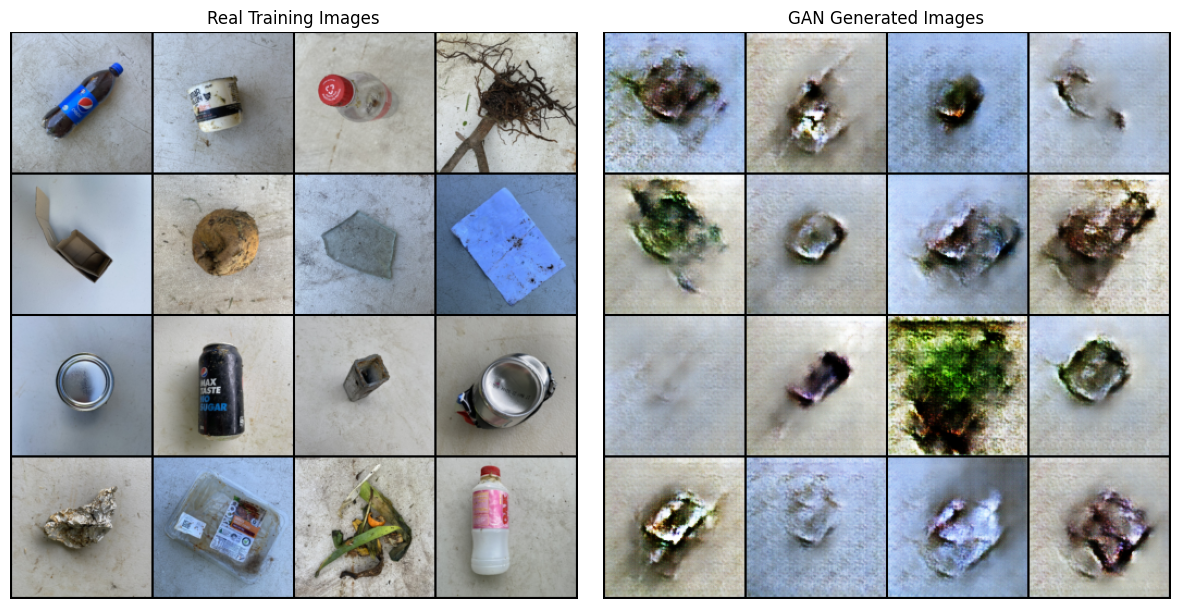

In [11]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# 1. Grab a single batch of real images from your loader
real_batch, _ = next(iter(train_loader))
real_batch = real_batch.to(device)

# Take up to 16 images for a clean 4x4 grid layout
num_images = min(16, real_batch.size(0))
real_samples = real_batch[:num_images]

# 2. Generate a matching number of fake images
with torch.no_grad():
    G.eval()
    # Create random noise matching the batch size
    noise = torch.randn(num_images, latent_dim, 1, 1).to(device)
    fake_samples = G(noise)
    G.train()

# 3. Create grid layouts (normalize=True rescales from [-1, 1] to)
grid_real = vutils.make_grid(real_samples, nrow=4, padding=2, normalize=True).cpu()
grid_fake = vutils.make_grid(fake_samples, nrow=4, padding=2, normalize=True).cpu()

# 4. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left Subplot: Real Images
axes[0].set_title("Real Training Images")
axes[0].imshow(grid_real.permute(1, 2, 0))
axes[0].axis("off")

# Right Subplot: Generated Images
axes[1].set_title("GAN Generated Images")
axes[1].imshow(grid_fake.permute(1, 2, 0))
axes[1].axis("off")

plt.tight_layout()
plt.show()
